In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv(r"C:\Users\BluRay\OneDrive\Desktop\BankingCustomerAnalysis\credit_card_customers_scaled.csv")

df.head()



,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.148757,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.732480,-0.707313,-0.724360,-0.810069,-0.579510,-1.447163,-0.824484,-0.829841,-0.556368,0.347262
1,0.948918,0.179616,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.732480,-0.916995,0.699592,0.784603,-1.379210,0.926060,1.065033,0.908184,0.391958,0.347262
2,0.824993,0.492710,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.466762,-0.916995,-0.724360,-0.810069,0.487865,1.010229,-0.119300,0.450407,-0.556368,0.347262
3,0.624653,-0.857867,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.363042,-0.916995,-0.213583,-0.123281,-0.874655,1.010229,-4.161996,-0.144271,-0.556368,0.347262
4,0.271260,0.492710,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.363042,-0.916995,-0.724360,-0.810069,-0.874655,-1.224909,-0.064979,-0.351833,-0.556368,0.347262


In [3]:
df.shape


(8950, 17)

## Determine Optimal Number of Clusters (Elbow Method)

In [4]:
inertia = []

K_range = range(1,11)

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    
    inertia.append(kmeans.inertia_)


C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend

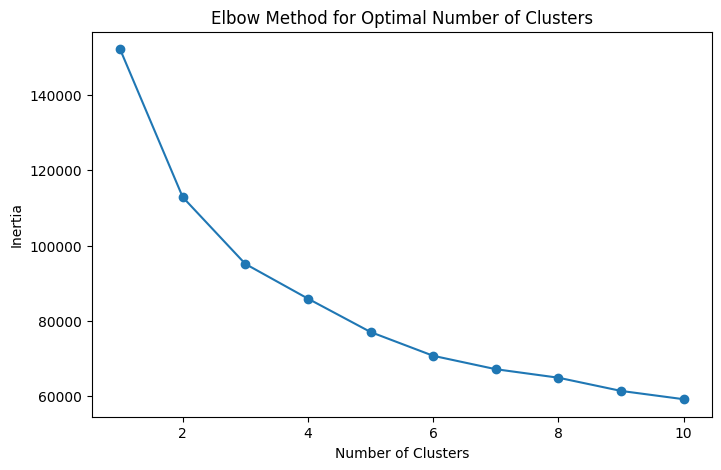

In [5]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()


## Evaluate Cluster Quality (Silhouette Score)

In [6]:
silhouette_scores = []

for k in range(2,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    labels = kmeans.fit_predict(df)
    
    score = silhouette_score(df, labels)
    
    silhouette_scores.append(score)


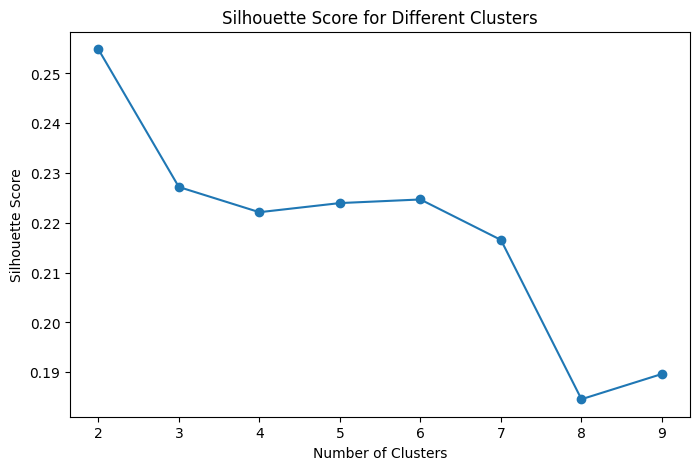

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(2,10), silhouette_scores, marker="o")

plt.title("Silhouette Score for Different Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.show()


## Train Final Clustering Model

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(df)


## Add Cluster Labels

In [9]:
df["Cluster"] = clusters

df.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,-1.205218,-0.148757,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.732480,-0.707313,-0.724360,-0.810069,-0.579510,-1.447163,-0.824484,-0.829841,-0.556368,0.347262,0
1,0.948918,0.179616,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.732480,-0.916995,0.699592,0.784603,-1.379210,0.926060,1.065033,0.908184,0.391958,0.347262,2
2,0.824993,0.492710,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.466762,-0.916995,-0.724360,-0.810069,0.487865,1.010229,-0.119300,0.450407,-0.556368,0.347262,3
3,0.624653,-0.857867,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.363042,-0.916995,-0.213583,-0.123281,-0.874655,1.010229,-4.161996,-0.144271,-0.556368,0.347262,0
4,0.271260,0.492710,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.363042,-0.916995,-0.724360,-0.810069,-0.874655,-1.224909,-0.064979,-0.351833,-0.556368,0.347262,0


## Cluster Size Distribution

In [10]:
df["Cluster"].value_counts()


Cluster
2    2733
3    2677
1    2022
0    1518
Name: count, dtype: int64

## Cluster Profiling

In [11]:
cluster_profile = df.groupby("Cluster").mean()

cluster_profile


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,-1.141405,-1.401911,-0.039434,0.091683,-0.527105,-0.647390,-0.647901,-0.234953,-0.656389,-0.597705,-0.638701,-0.463177,-0.264100,-0.834114,-0.810068,-0.030839,-0.118278
1,-0.577775,0.154636,0.417194,-0.655610,0.868160,-0.732062,0.789214,-0.592496,0.992928,-0.614147,-0.670024,0.478478,-0.457259,-0.219686,-0.397900,0.541150,-0.062458
2,0.616417,0.260346,-1.126272,-0.602225,-0.923042,1.026241,-1.039441,-0.565340,-0.840563,0.897454,0.956750,-1.069641,-0.012029,0.111913,0.432926,-0.426865,-0.089590
3,0.454331,0.412365,0.857078,1.058031,0.585506,-0.127662,0.832468,1.157923,0.480371,-0.113419,-0.108502,0.993257,0.507418,0.524666,0.317912,0.044539,0.205710


In [17]:
cluster_profile.T


Cluster,0,1,2,3
BALANCE,-1.141405,-0.577775,0.616417,0.454331
BALANCE_FREQUENCY,-1.401911,0.154636,0.260346,0.412365
PURCHASES,-0.039434,0.417194,-1.126272,0.857078
ONEOFF_PURCHASES,0.091683,-0.655610,-0.602225,1.058031
INSTALLMENTS_PURCHASES,-0.527105,0.868160,-0.923042,0.585506
CASH_ADVANCE,-0.647390,-0.732062,1.026241,-0.127662
PURCHASES_FREQUENCY,-0.647901,0.789214,-1.039441,0.832468
ONEOFF_PURCHASES_FREQUENCY,-0.234953,-0.592496,-0.565340,1.157923
PURCHASES_INSTALLMENTS_FREQUENCY,-0.656389,0.992928,-0.840563,0.480371
CASH_ADVANCE_FREQUENCY,-0.597705,-0.614147,0.897454,-0.113419


## Dimensionality Reduction with PCA

In [12]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(df.drop("Cluster", axis=1))


## Create PCA DataFrame

In [13]:
pca_df = pd.DataFrame(pca_data, columns=["PC1","PC2"])

pca_df["Cluster"] = df["Cluster"]


## Visualize Customer Segments

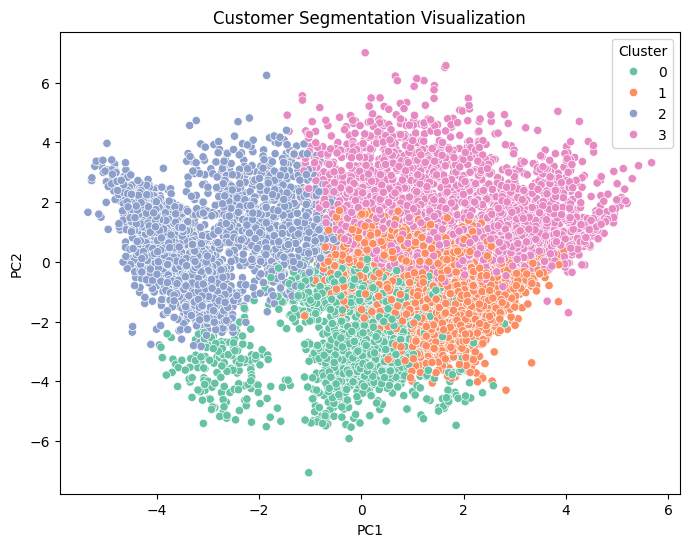

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set2"
)

plt.title("Customer Segmentation Visualization")

plt.show()


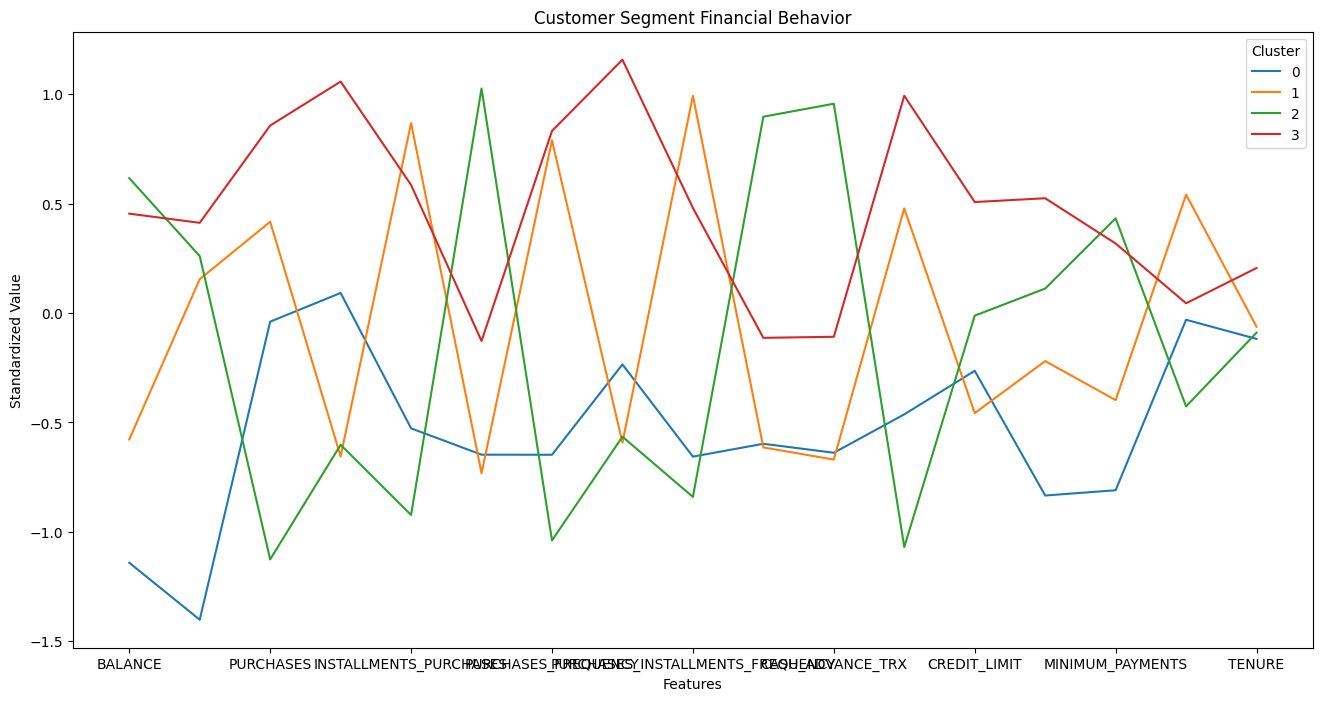

In [18]:
cluster_profile.T.plot(figsize=(16,8))

plt.title("Customer Segment Financial Behavior")

plt.xlabel("Features")

plt.ylabel("Standardized Value")

plt.show()


In [15]:
df.to_csv("customer_segments.csv", index=False)


## Customer Segmentation Insights

Cluster 0
Customers with low spending and low credit usage.

Cluster 1
High-value customers with large purchases and high balances.

Cluster 2
Customers frequently using cash advances, indicating possible liquidity needs.

Cluster 3
Financially disciplined customers who regularly make payments and maintain moderate balances.
